# 01 - Exploratory Data Analysis
**EduAlert: Early Identification of At-Risk Students Using Data Mining**

Data is *synthetic* (see `src/data_generation.py`). The target `Risk_Level` is derived from a later outcome (`Final_Score`), which is never used as a predictor.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
from IPython.display import Image, display
from src.utils import *
df = pd.read_csv(PROCESSED_PATH)
print(df.shape)
df.head()

(6000, 23)


,Student_ID,Age,Gender,Department,Semester,Previous_GPA,Attendance_Percentage,Assignment_Avg,Quiz_Avg,Midterm_Score,...,Assignments_Missed,Late_Submissions,Participation_Score,Previous_Backlogs,Final_Score,Risk_Level,Assessment_Avg,Attendance_Status,Engagement_Score,Academic_Performance_Index
0,STU00001,20,Male,Computer Science,5,6.94,79.1,75.5,67.1,69.8,...,1,2,56.2,0,58.1,Medium,70.22,1,68.48,72.16
1,STU00002,20,Female,Computer Science,3,5.90,70.8,65.0,55.1,59.0,...,0,1,54.3,0,60.1,Medium,60.42,1,65.72,62.52
2,STU00003,20,Male,Electronics,6,7.73,93.9,79.8,68.9,83.0,...,0,3,64.7,0,80.4,Low,76.45,0,82.38,81.11
3,STU00004,20,Male,Electronics,6,6.93,92.4,75.7,93.3,76.7,...,2,2,61.9,1,85.7,Low,81.30,0,67.26,79.88
4,STU00005,20,Female,Civil,3,4.15,46.0,25.9,15.1,23.0,...,4,5,59.5,3,12.5,High,22.62,2,42.80,35.08


## Data quality (raw -> processed)

In [2]:
from src.data_preprocessing import clean
raw = pd.read_csv(RAW_PATH)
_, summary = clean(raw)
summary

{'rows_in': 6040,
 'duplicates_removed': 40,
 'invalid_values_nulled': 16,
 'missing_before_imputation': 506,
 'outliers_capped': 0,
 'rows_out': 6000}

## Target distribution

In [3]:
df['Risk_Level'].value_counts(normalize=True).round(3)

Risk_Level
Low       0.522
Medium    0.308
High      0.170
Name: proportion, dtype: float64

## Q1-Q4: what drives risk?

In [4]:
from src.eda import run
stats = run(df)
stats

[eda] figures saved to /home/claude/Early-Identification-At-Risk-Students/reports/figures; {'corr_attendance_final': np.float64(0.722), 'corr_gpa_final': np.float64(0.812), 'high_risk_share_by_missed': {0: 0.053, 1: 0.137, 2: 0.249, 3: 0.341, 4: 0.505, 5: 0.553, 6: 0.611}}


{'corr_attendance_final': np.float64(0.722),
 'corr_gpa_final': np.float64(0.812),
 'high_risk_share_by_missed': {0: 0.053,
  1: 0.137,
  2: 0.249,
  3: 0.341,
  4: 0.505,
  5: 0.553,
  6: 0.611}}

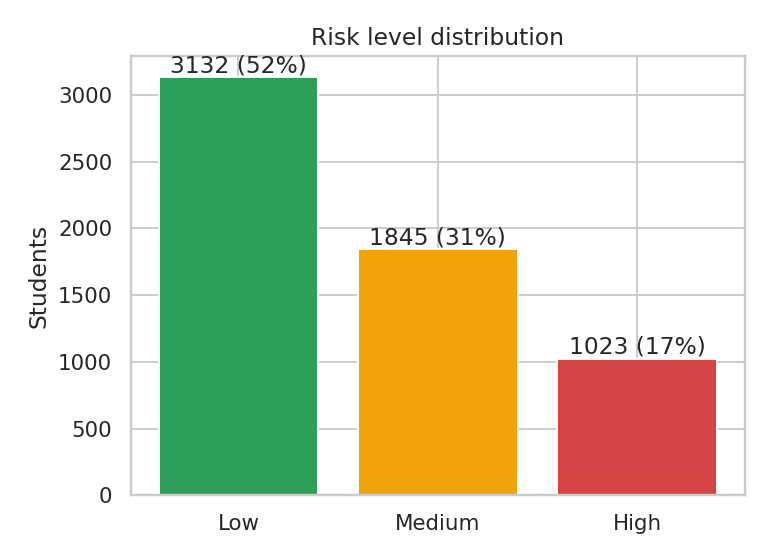

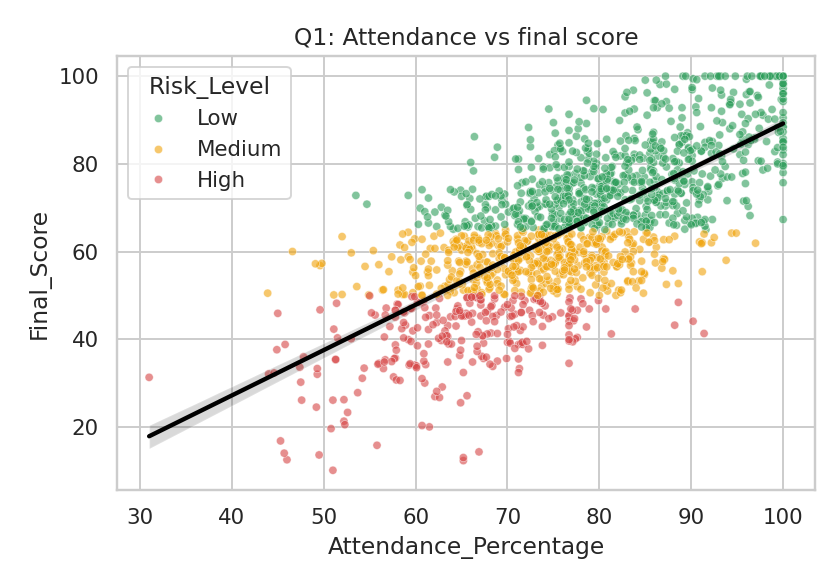

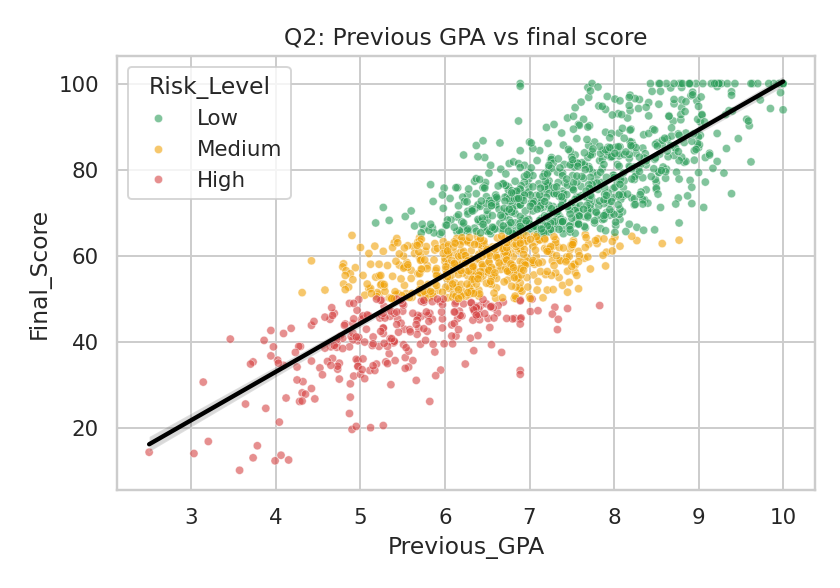

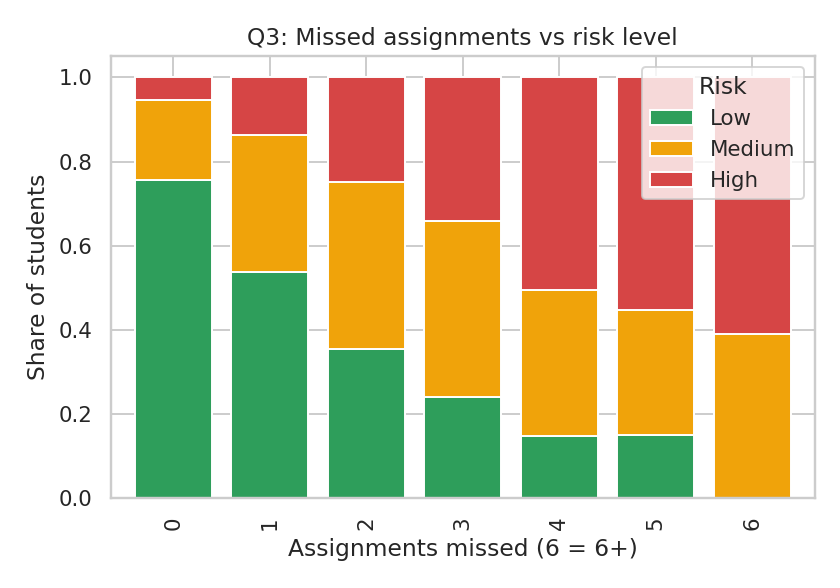

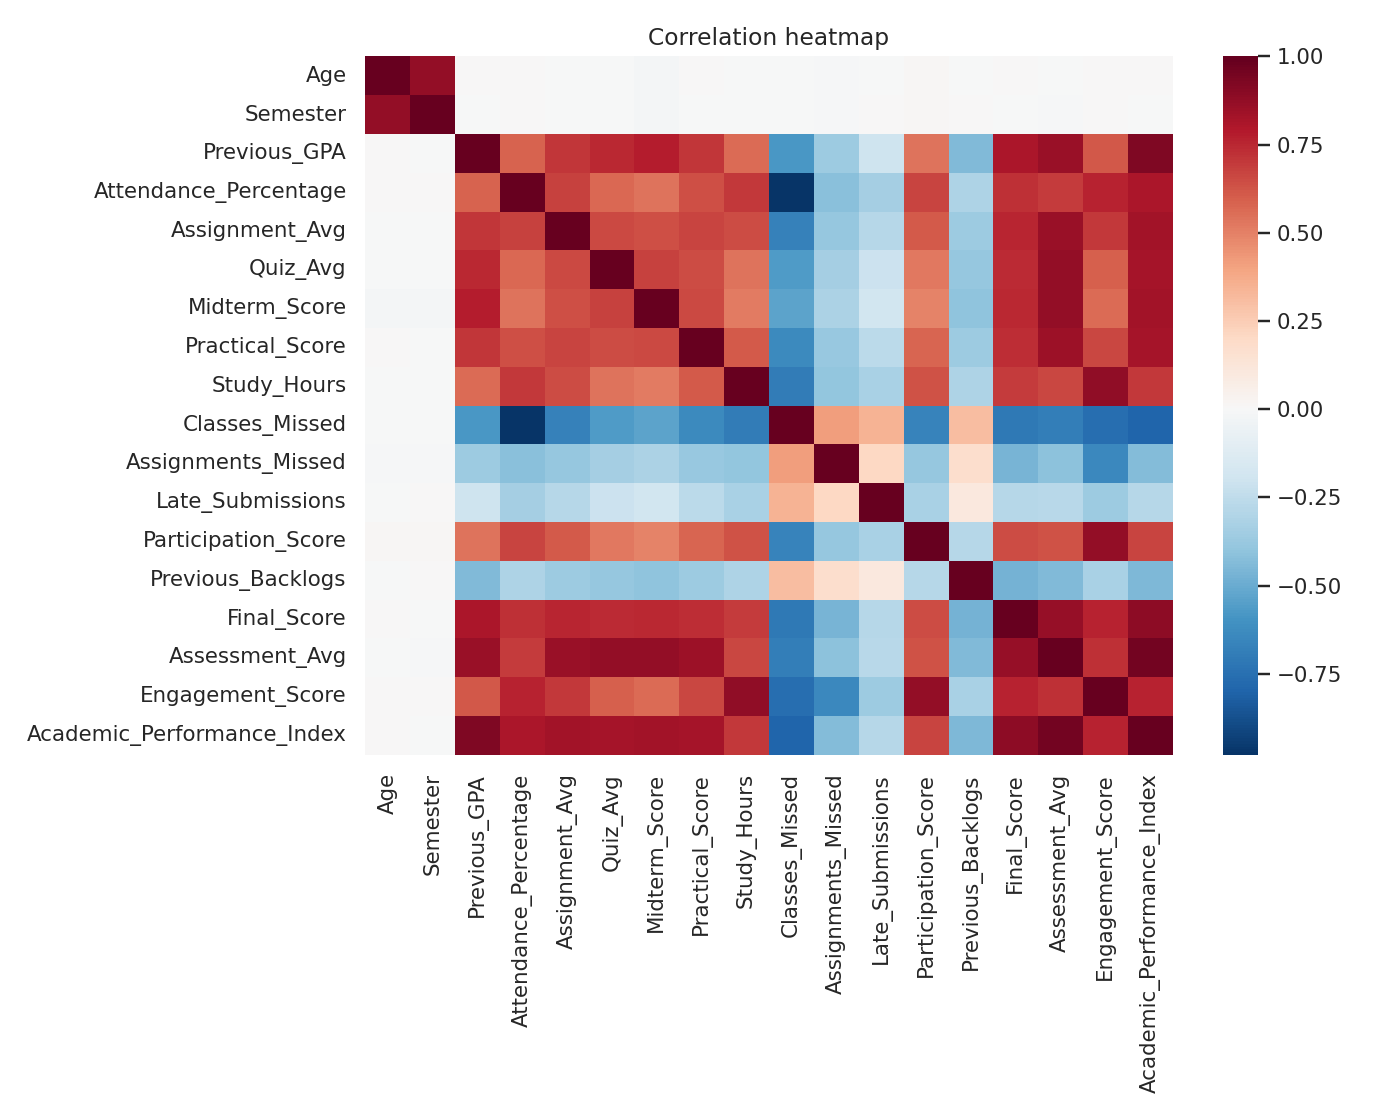

In [5]:
for f in ['eda_risk_distribution','eda_attendance_vs_final','eda_gpa_vs_final','eda_missed_assignments_vs_risk','eda_correlation_heatmap']:
    display(Image(str(FIG_DIR / f'{f}.png'), width=520))

**Findings.** Attendance and previous GPA are strongly correlated with final score, and the share of High-risk students rises steadily with the number of missed assignments (Q3 chart).